In [1]:
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import matplotlib.pyplot as plt

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [2]:
# published metadata
metacells = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/human_MTG_2018-06-14_samples-columns.csv"
# read in metacells 
cells_pub = pd.read_csv(metacells)
cells_pub.head()

,sample_name,sample_id,sample_type,organism,donor,sex,age_days,brain_hemisphere,brain_region,brain_subregion,...,percent_mt_exon_reads,percent_reads_unique,percent_synth_reads,percent_ecoli_reads,percent_aligned_reads_total,complexity_cg,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,class,cluster
0,F1S4_160106_001_B01,556012415,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.090052,85.573696,0.007535,0.018537,92.418885,0.316637,8635,5253,GABAergic,Inh L4-6 SST B3GAT2
1,F1S4_160106_001_C01,556012410,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.052470,87.619777,0.002790,0.007265,94.001319,0.287989,11697,8246,Glutamatergic,Exc L5-6 RORB TTC12
2,F1S4_160106_001_E01,556012412,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.042946,86.448562,0.004573,0.006413,92.871217,0.280933,12138,8467,Glutamatergic,Exc L5-6 FEZF2 ABO
3,F1S4_160106_001_G01,556012414,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055851,84.497105,0.006585,0.008131,90.198132,0.293406,12191,8287,Glutamatergic,Exc L5-6 FEZF2 EFTUD1P1
4,F1S4_160106_001_H01,556012409,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055692,87.014752,0.005061,0.011116,93.460676,0.293106,10535,6922,Glutamatergic,Exc L3-5 RORB ESR1


In [3]:
# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [5]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file='/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet.h5'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  12748
Number of junctions after removing singletons:  12748
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  208
The number of unique junctions in the data is:  12749
The maximum junction count was initially:  5117
0
The maximum junction count is now:  5117
The number of junctions in the data is:  12749
The number of cells in the data is:  208
The number of cell types in the data is:  4
The number of cells going into training data is:
208
208
The number of junctions is:  12749
The number of intron clusters observed is:  4677
The number of genes is:  3297
The number of cells is:  208


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [6]:
cell_ids_conversion.head()

,cell_id_index,cell_id,cell_type
0,0,F2S4_170405_005_A01,no class
1635,1,F2S4_170405_005_B01,no class
3477,2,F2S4_170405_005_C01,no class
4826,3,F2S4_170405_005_D01,Glutamatergic
5140,4,F2S4_170405_005_E01,Glutamatergic


In [7]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [8]:
simple_data

,cell_id_index,Cluster,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,4,0,1.000000,2.0,2,1_150150287_150150911,ENSG00000023902.14
1,0,5,1,1.000000,9.0,9,1_150151058_150158818,ENSG00000023902.14
2,0,7,2,1.000000,8.0,8,1_69678478_69760190,ENSG00000033122.21
3,0,20,3,1.000000,4.0,4,1_16970767_16971464,ENSG00000058453.17
4,0,35,4,0.857143,6.0,7,1_172551626_172553259,ENSG00000094975.15
...,...,...,...,...,...,...,...,...
644568,207,4683,12723,0.000000,0.0,11,15_99317546_99333922,ENSG00000168904.15
644569,207,1317,12725,0.000000,0.0,7,3_49676219_49676608,ENSG00000164062.13
644570,207,4903,12738,0.000000,0.0,3,16_2082504_2083694,ENSG00000103197.19
644571,207,5679,12739,1.000000,6.0,6,19_10544325_10544708,ENSG00000130734.10


In [9]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [10]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [11]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [12]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [13]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.7569292765043412


### Evaluate performance on imputation/masking task

In [14]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [15]:
cluster_counts

<208x12749 sparse matrix of type '<class 'numpy.int64'>'
	with 644573 stored elements in COOrdinate format>

In [16]:
#1. get masked matrix using intron cluster counts for this mouse brain data 
perc_mask = 0.3
seeds_used = []
masks_list = []

print("The masking percentage is: " + str(perc_mask))
masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
seeds_used.append(seed)
masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices via masked values 
masked_counts = []
i=0
print("The masking percentage is: " + str(perc_mask))
masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
# appent masked junction and intron cluster counts to list
masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 
masked_junction_counts, masked_intron_clusts = masked_counts[i]
# get y_tensor and total_counts_tensor via prep_model_input function
y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
# append to model_input_files list
model_input_files.append((y_tensor, total_counts_tensor))

The masking percentage is: 0.3
The seed is:  194312
[112794 600520 103303 487171 100970 443375 561469 621603 601831  28271
 281487   7151 242698 415410  87412 596857 469441 611709   3592 167562
 200205 258860  19429 353115 566622  42913 321156 285516 396864 386180
 449591 165141  27075 297218 324686 461169 485282 268627 234984 327261
 432641 111357 154467  56635 217108 300385 641929 235525 135998 102768]
Number of entries (junction-cell pairs) masked:  193371.0
The masking percentage is: 0.3


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:141: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


In [17]:
# Now can run factor model on masked data
Ks = [2, 3, 5, 10, 20, 50, 100, 500]
all_Ks_results = {}

# Seeds used for masking 
seeds_used 

import random

# Generate a list of 50 different seeds
seeds = random.sample(range(1000), 10)  # Assuming you want seeds up to 1000

print(seeds)

# make input conc infinity first 
input_conc = torch.tensor(np.inf, **float_type)

#import torch.distributions as dist
#input_conc = dist.Gamma(concentration=2.0, rate=2.0)
i=0 

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    print("The masking percentage is: " + str(perc_mask))
    y_tensor, total_counts_tensor = model_input_files[i]
    # run factor model
    masked_results = factor_model.main(y_tensor, total_counts_tensor, use_global_prior=False, K=k, seeds=seeds,loss_plot=False, num_epochs=100, lr = 0.05, save_to_file = False)
    # save results to dictionary
    all_Ks_results[(k, perc_mask)] = masked_results

[790, 129, 260, 723, 487, 630, 632, 400, 847, 857]
------------------------------------------------
Running factor model for K = 2
------------------------------------------------
The masking percentage is: 0.3
Not using priors on a and b, running simpler non-hierarchical version!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter 1.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 790
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1072838.0876347653
Epoch 40, Elbo loss: 853580.2310385596
Epoch 80, Elbo loss: 835970.1323982286


Elbo loss: 834242.7362018882


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 129
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1139917.1218752991
Epoch 40, Elbo loss: 865418.6285880473
Epoch 80, Elbo loss: 838643.6149516465


Elbo loss: 835740.2442428477


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 260
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1053034.1758280345
Epoch 40, Elbo loss: 860167.1714162584
Epoch 80, Elbo loss: 837889.2979280333


...

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 9 with seed 847
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 18129229.25675401
Epoch 40, Elbo loss: 2352222.635772964


Elbo loss: 1451881.2881512996


Stopping early at epoch 62. Best Elbo Loss: 1404880.724583812
Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 10 with seed 857
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 18057644.84211916
Epoch 40, Elbo loss: 2395578.847199397


Elbo loss: 1686019.787488427


Stopping early at epoch 63. Best Elbo Loss: 1458657.0940133147
Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [18]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []
i=0
for k in Ks:
    print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
    masked_results = all_Ks_results[(k, perc_mask)]        
    for res in masked_results:
        # get seed that was used 
        seed = res['seed']
        # get latent variables
        psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
        assign_post=res['latent_vars']["assign"]
        # get K 
        K = psi.shape[0]
        J = psi.shape[1]
        # get scores 
        mask_matrix_used = masks_list[i]
        l1, r, l2, rmse, loglik = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)
        # get num epochs trained for 
        nepoch = len(res["losses"])
        # save to list 
        masked_perf.append([seed, l1, r, l2, rmse, loglik, K, perc_mask, J, nepoch])

Calculating performance for K = 2 and masking percentage = 0.3


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:263: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.270972957223088
Spearman correlation:  0.48119951468598166
L2 error:  0.1243556693856926
RMSE:  0.3526409922083543
Log-likelihood:  -1845827.5275383599
L1 error:  0.2719886706029322
Spearman correlation:  0.48333123983763937
L2 error:  0.12380740538514395
RMSE:  0.35186276498820385
Log-likelihood:  -1857262.5524464385
L1 error:  0.27170717885325874
Spearman correlation:  0.48223806150120635
L2 error:  0.1244039505963231
RMSE:  0.35270944217063865
Log-likelihood:  -1838030.031459128
L1 error:  0.27062943115798604
Spearman correlation:  0.4817727179607558
L2 error:  0.12444371122801666
RMSE:  0.3527658022371452
Log-likelihood:  -1825568.2969854532
L1 error:  0.2712708141896481
Spearman correlation:  0.4885120425372924
L2 error:  0.1224490133879066
RMSE:  0.34992715440203637
Log-likelihood:  -1867918.6664263431
L1 error:  0.27148462021193515
Spearman correlation:  0.4791626974430469
L2 error:  0.12491710995297413
RMSE:  0.3534361469246943
Log-likelihood:  -1856847.4048073147


In [19]:
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "loglik", "K",  "perc_masked" , "J", "num_epochs"])

In [20]:
masked_perf_df

,seed,l1,r,l2,rmse,loglik,K,perc_masked,J,num_epochs
0,790,0.270973,0.481200,0.124356,0.352641,-1.845828e+06,2,0.3,12749,100
1,129,0.271989,0.483331,0.123807,0.351863,-1.857263e+06,2,0.3,12749,100
2,260,0.271707,0.482238,0.124404,0.352709,-1.838030e+06,2,0.3,12749,100
3,723,0.270629,0.481773,0.124444,0.352766,-1.825568e+06,2,0.3,12749,100
4,487,0.271271,0.488512,0.122449,0.349927,-1.867919e+06,2,0.3,12749,100
...,...,...,...,...,...,...,...,...,...,...
75,630,0.373577,0.301849,0.164426,0.405495,-3.896368e+06,500,0.3,12749,56
76,632,0.311544,0.442562,0.134130,0.366238,-2.260919e+06,500,0.3,12749,100
77,400,0.308363,0.448218,0.130284,0.360949,-2.179182e+06,500,0.3,12749,100
78,847,0.362036,0.341721,0.156970,0.396195,-3.119113e+06,500,0.3,12749,63


In [21]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

,seed,l1,r,l2,rmse,loglik,K,perc_masked,J,num_epochs,seed_perc_masked
0,790,0.270973,0.481200,0.124356,0.352641,-1.845828e+06,2,0.3,12749,100,790_0.3
1,129,0.271989,0.483331,0.123807,0.351863,-1.857263e+06,2,0.3,12749,100,129_0.3
2,260,0.271707,0.482238,0.124404,0.352709,-1.838030e+06,2,0.3,12749,100,260_0.3
3,723,0.270629,0.481773,0.124444,0.352766,-1.825568e+06,2,0.3,12749,100,723_0.3
4,487,0.271271,0.488512,0.122449,0.349927,-1.867919e+06,2,0.3,12749,100,487_0.3


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

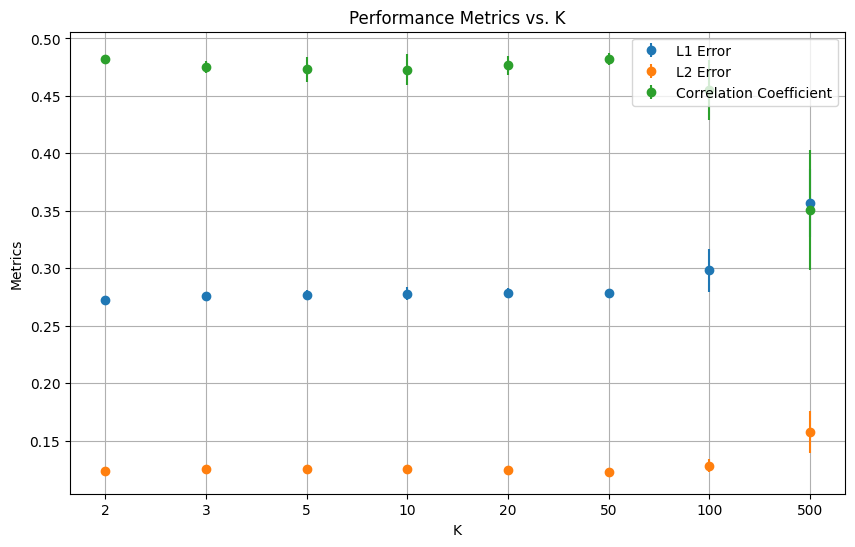

In [22]:
# Group by 'K' and calculate mean and standard deviation for each metric
grouped_data = masked_perf_df.groupby('K').agg({'l1': ['mean', 'std'], 'r': ['mean', 'std'], 'l2': ['mean', 'std'], 'loglik': ['mean', 'std']})

# Extract mean and std for each metric
K_values = grouped_data.index.astype(str)  # Convert K to string
l1_means = grouped_data['l1']['mean']
l1_std = grouped_data['l1']['std']
r_means = grouped_data['r']['mean']
r_std = grouped_data['r']['std']
l2_means = grouped_data['l2']['mean']
l2_std = grouped_data['l2']['std']
ll_means = grouped_data['loglik']['mean']
ll_std = grouped_data['loglik']['std']

# Plotting
plt.figure(figsize=(10, 6))

# L1 Error
plt.errorbar(K_values, l1_means, yerr=l1_std, fmt='o', label='L1 Error')

# L2 Error
plt.errorbar(K_values, l2_means, yerr=l2_std, fmt='o', label='L2 Error')

# Correlation Coefficient
plt.errorbar(K_values, r_means, yerr=r_std, fmt='o', label='Correlation Coefficient')

# Labels and Title
plt.xlabel('K')
plt.ylabel('Metrics')
plt.title('Performance Metrics vs. K')
plt.legend()
plt.grid(True)

plt.show()

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<ErrorbarContainer object of 3 artists>

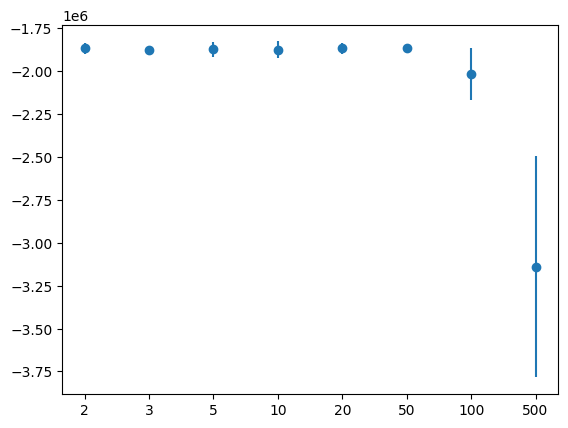

In [23]:
plt.errorbar(K_values, ll_means, yerr=ll_std, fmt='o', label='Log-lik')

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


ValueError: x and y must have same first dimension, but have shapes (8,) and (80,)

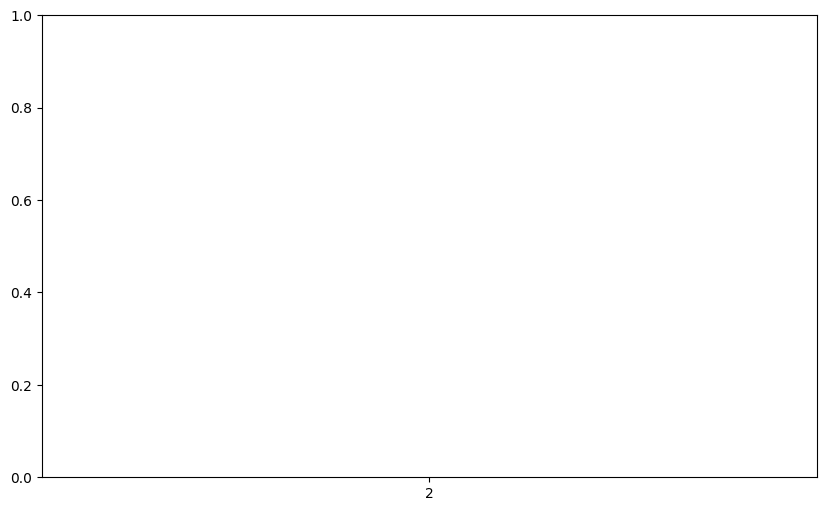

In [24]:
# Plotting
plt.figure(figsize=(10, 6))

# L1 Error
plt.plot(K_values, masked_perf_df["l1"], marker='o', label='L1 Error')

# L2 Error
plt.plot(K_values, masked_perf_df["l2"], marker='o', label='L2 Error')

# Correlation Coefficient
plt.plot(K_values, masked_perf_df["r"], marker='o', label='Correlation Coefficient')

# Labels and Title
plt.xlabel('K')
plt.ylabel('Metrics')
plt.title('Performance Metrics vs. K')
plt.xticks(K_values)
plt.legend()
plt.grid(True)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


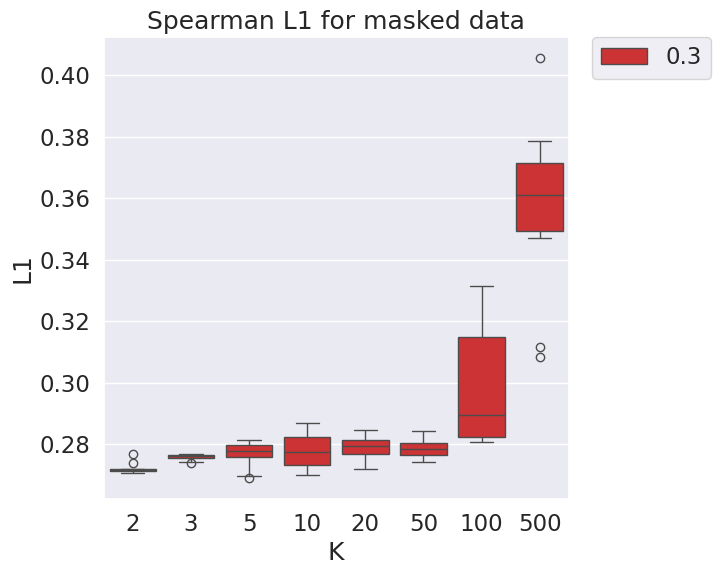

0.2688611584797701


In [25]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


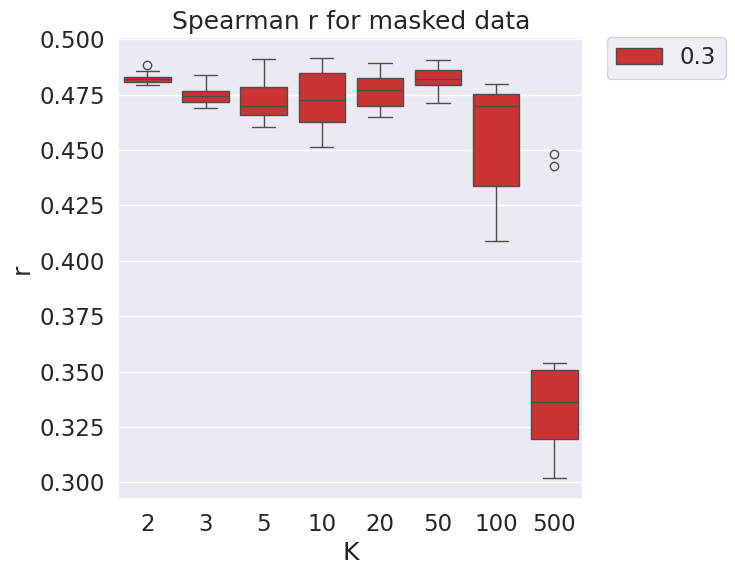

0.4913767636216991


In [26]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


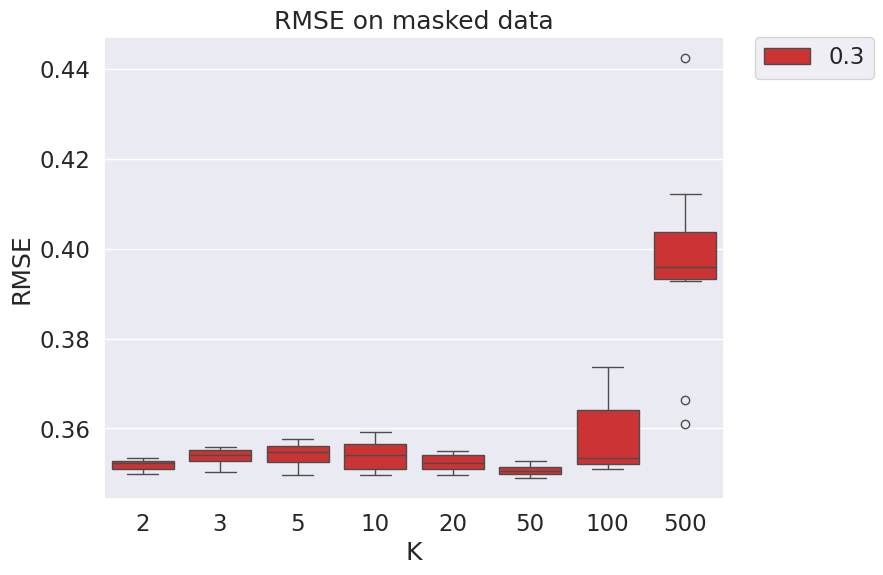

0.3489213654359065


In [27]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


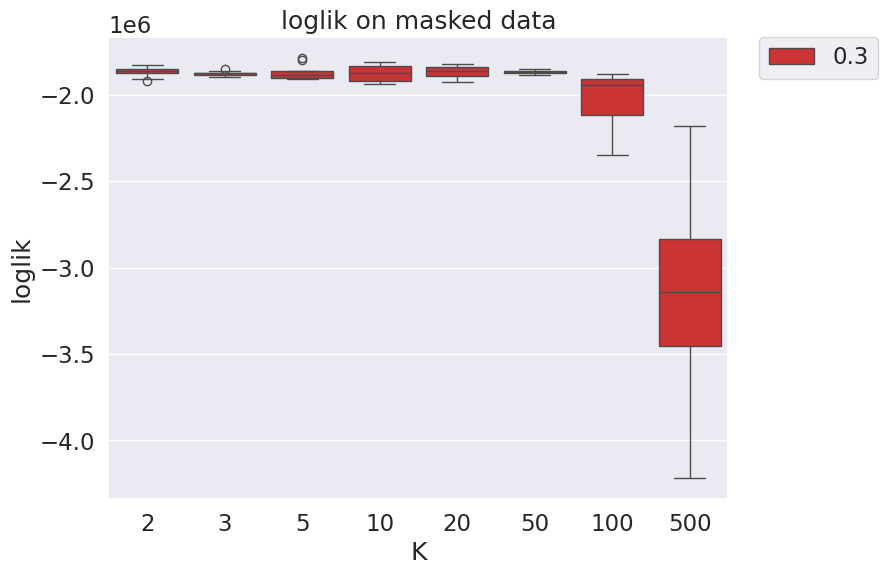

0.3489213654359065


In [28]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="loglik", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("loglik")
ax.set_title("loglik on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

In [29]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
median_l2 = masked_perf_df.groupby(["K"])["l2"].median()
median_rmse = masked_perf_df.groupby(["K"])["rmse"].median()
median_loglik = masked_perf_df.groupby(["K"])["loglik"].median()

# find K that gives the lowest l1 error and print it
min_l1 = median_l1.idxmin()
print("The K that gives the lowest median l1 error is: " + str(min_l1))

# find K that gives the lowest l2 error and print it
min_l2 = median_l2.idxmin()
print("The K that gives the lowest median l2 error is: " + str(min_l2))

# find K that gives the highest r and print it
max_r = median_r.idxmax()
print("The K that gives the highest median r is: " + str(max_r))

# find K that gives the lowest rmse and print it
min_rmse = median_rmse.idxmin()
print("The K that gives the lowest median rmse is: " + str(min_rmse))

# find K that gives the highest loglik and print it
max_loglik = median_loglik.idxmax()
print("The K that gives the higher median Log Likelihood is: " + str(max_loglik))

The K that gives the lowest median l1 error is: 2
The K that gives the lowest median l2 error is: 50
The K that gives the highest median r is: 2
The K that gives the lowest median rmse is: 50
The K that gives the higher median Log Likelihood is: 2


### Run full factor model

In [30]:
reload(factor_model)

2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter 1.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 3620
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1673169.5721182842
Epoch 40, Elbo loss: 1210344.526277429
Epoch 80, Elbo loss: 1198944.229105622
Epoch 120, Elbo loss: 1196543.2516545604


Elbo loss: 1195386.9564441224


Stopping early at epoch 143. Best Elbo Loss: 1195246.060312386


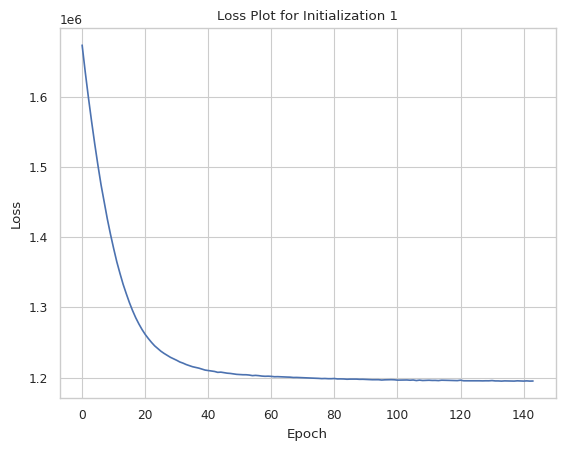

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 8573
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1672020.7636912283
Epoch 40, Elbo loss: 1211240.1334424
Epoch 80, Elbo loss: 1198032.3223996963
Epoch 120, Elbo loss: 1195499.9283055435
Epoch 160, Elbo loss: 1194896.965785571


Elbo loss: 1194905.641802754


Stopping early at epoch 176. Best Elbo Loss: 1194511.4169682593


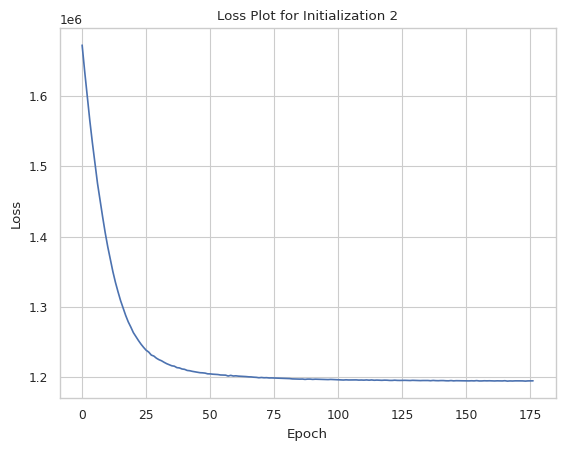

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [109]:
best_K = 2
K = best_K

# make input conc infinity first 
# input_conc = torch.tensor(np.inf, **float_type)

# import torch.distributions as dist
# input_conc = dist.Gamma(concentration=2.0, rate=2.0)

#input_conc = 1
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=True, K=K, lr=0.1, loss_plot=True, num_epochs=500, save_to_file = False)

In [110]:
import pyro
# fetch optimized guide parameters, each (loc, scale) pair parameterizes a single normal distribution in the guide corresponding to a different unobserved pyro.sample statement in the model
for name, value in pyro.get_param_store().items():
    print(name, pyro.param(name))

AutoDiagonalNormal.loc Parameter containing:
tensor([ 0.0980, -1.0894,  0.0470,  ...,  0.1498, -3.5685, -2.4779],
       requires_grad=True)
AutoDiagonalNormal.scale tensor([0.6858, 0.5153, 0.6765,  ..., 0.0964, 0.4867, 0.3200],
       grad_fn=<SoftplusBackward0>)


In [111]:
# extract latent variables for just first seed used 
latent_vars = all_results[1]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

dir_conc = latent_vars["dir_conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))

[0.7009417  0.23838566 0.49534363 ... 1.054757   1.1728885  0.3545181 ]
[0.3300349  3.1076148  1.6655711  ... 0.7564559  0.65632385 9.351891  ]
The inferred concentration parameter is: 1.791298
The inferred pi parameter is: [0.46211866 0.5378814 ]


In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

plot_bb = False 

if plot_bb:

    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    # Calculate the probability density function (PDF) of the beta distribution
    pdf = beta.pdf(x, a, b)

    # Plot the beta distribution
    plt.plot(x, pdf)
    plt.title('Beta Distribution')
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()

In [113]:
assign_post.shape

(208, 2)

In [114]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [115]:
cell_ids_conversion

,cell_id_index,cell_id,cell_type,clean_cell_type
0,0,F2S4_170405_005_A01,no class,no class
1635,1,F2S4_170405_005_B01,no class,no class
3477,2,F2S4_170405_005_C01,no class,no class
4826,3,F2S4_170405_005_D01,Glutamatergic,Glutamatergic
5140,4,F2S4_170405_005_E01,Glutamatergic,Glutamatergic
...,...,...,...,...
326817,203,F2S4_170405_032_C01,Glutamatergic,Glutamatergic
328395,204,F2S4_170405_032_E01,Glutamatergic,Glutamatergic
329488,205,F2S4_170405_032_F01,GABAergic,GABAergic
330760,206,F2S4_170405_032_G01,Glutamatergic,Glutamatergic


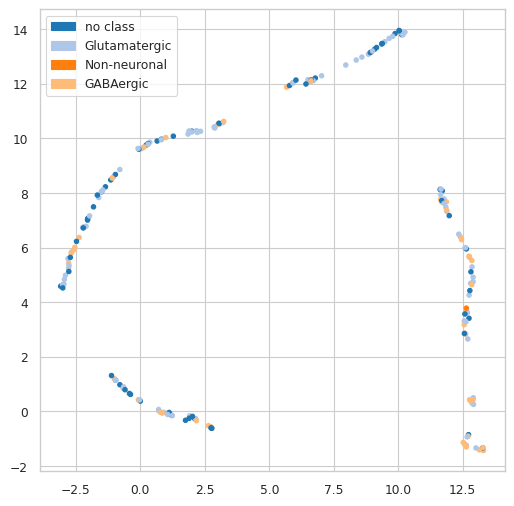

In [116]:
# plot UMAP 
# add whitegrid 
import matplotlib.patches as mpatches

sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=10, c=cell_colors
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

In [117]:
cell_types.value_counts()

cell_type
Glutamatergic    92
no class         65
GABAergic        49
Non-neuronal      2
Name: count, dtype: int64

In [118]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

array([0.46211866, 0.5378814 ], dtype=float32)

         pi    Factor
1  0.537881  Facotor1
0  0.462119  Facotor0


/scratch/ipykernel_139811/540431722.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

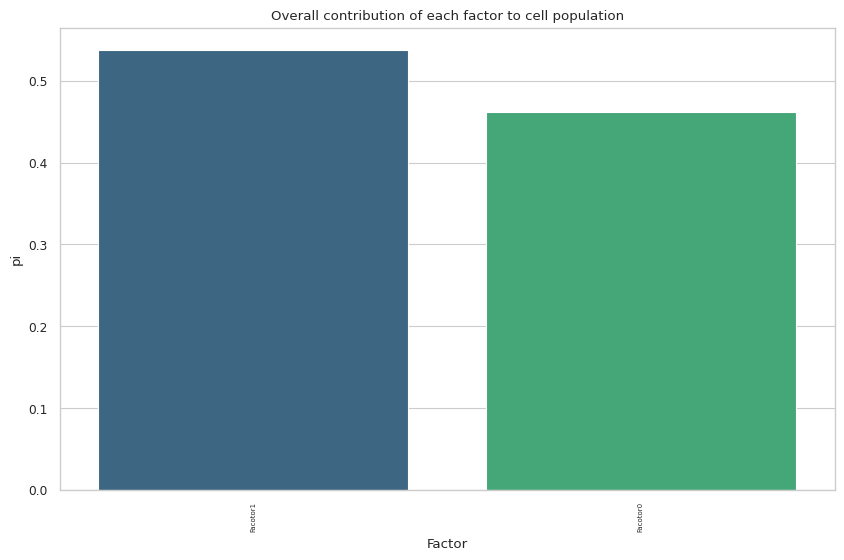

In [119]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [120]:
# which splice junctions are very activated in factor 8 
psi = latent_vars["psi"]

# convert into a data frame
psi_df = pd.DataFrame(psi)
psi_df

,0,1,2,3,4,5,6,7,8,9,...,12739,12740,12741,12742,12743,12744,12745,12746,12747,12748
0,0.428450,0.013802,0.718347,0.156615,0.300436,0.240117,0.472313,0.645467,0.719480,0.159582,...,0.118880,0.442823,0.168112,0.087965,0.352806,0.028480,0.225244,0.139516,0.815801,0.070959
1,0.209477,0.073462,0.249502,0.345852,0.556059,0.476679,0.077547,0.487960,0.203357,0.287148,...,0.517094,0.033202,0.544803,0.159905,0.074539,0.124648,0.017733,0.434041,0.470871,0.103642


In [121]:
cell_ids_conversion["cell_type"].unique()

array(['no class', 'Glutamatergic', 'Non-neuronal', 'GABAergic'],
      dtype=object)

In [122]:
cell_ids_conversion["clean_cell_type"] = cell_ids_conversion["cell_type"]

# replace 
cell_ids_conversion["clean_cell_type"][cell_ids_conversion["cell_type"] == 'Non-neuronal'] = "no class"
cell_ids_conversion

/scratch/ipykernel_139811/1471581423.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cell_ids_conversion["clean_cell_type"][cell_ids_conversion["cell_type"] == 'Non-neuronal'] = "no class"
/scratch/ipykernel_139811/1471581423.py:4: Setti

,cell_id_index,cell_id,cell_type,clean_cell_type
0,0,F2S4_170405_005_A01,no class,no class
1635,1,F2S4_170405_005_B01,no class,no class
3477,2,F2S4_170405_005_C01,no class,no class
4826,3,F2S4_170405_005_D01,Glutamatergic,Glutamatergic
5140,4,F2S4_170405_005_E01,Glutamatergic,Glutamatergic
...,...,...,...,...
326817,203,F2S4_170405_032_C01,Glutamatergic,Glutamatergic
328395,204,F2S4_170405_032_E01,Glutamatergic,Glutamatergic
329488,205,F2S4_170405_032_F01,GABAergic,GABAergic
330760,206,F2S4_170405_032_G01,Glutamatergic,Glutamatergic


In [123]:
cell_ids_conversion["clean_cell_type"].unique()

array(['no class', 'Glutamatergic', 'GABAergic'], dtype=object)

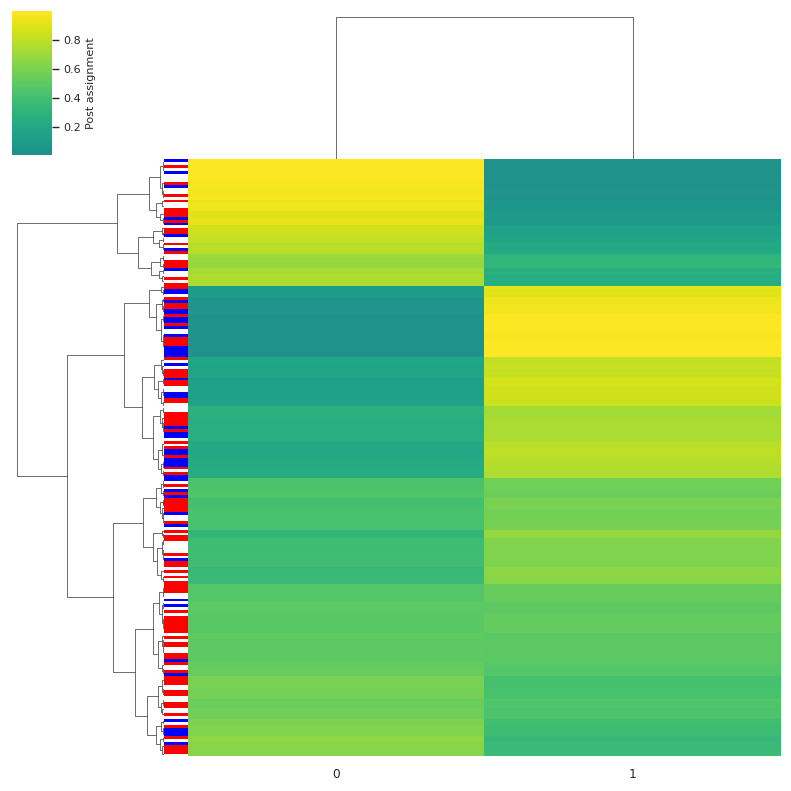

In [124]:
import seaborn as sns

# Define your custom color palette
custom_palette = ["white", "red", "blue"]

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['clean_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = custom_palette[:num_unique_types]  # Ensure you have enough colors in your custom palette

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.clean_cell_type.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

# Set label for color bar
cluster.cax.set_ylabel('Post assignment', size=8)

# Increase font size for color bar tick labels
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)


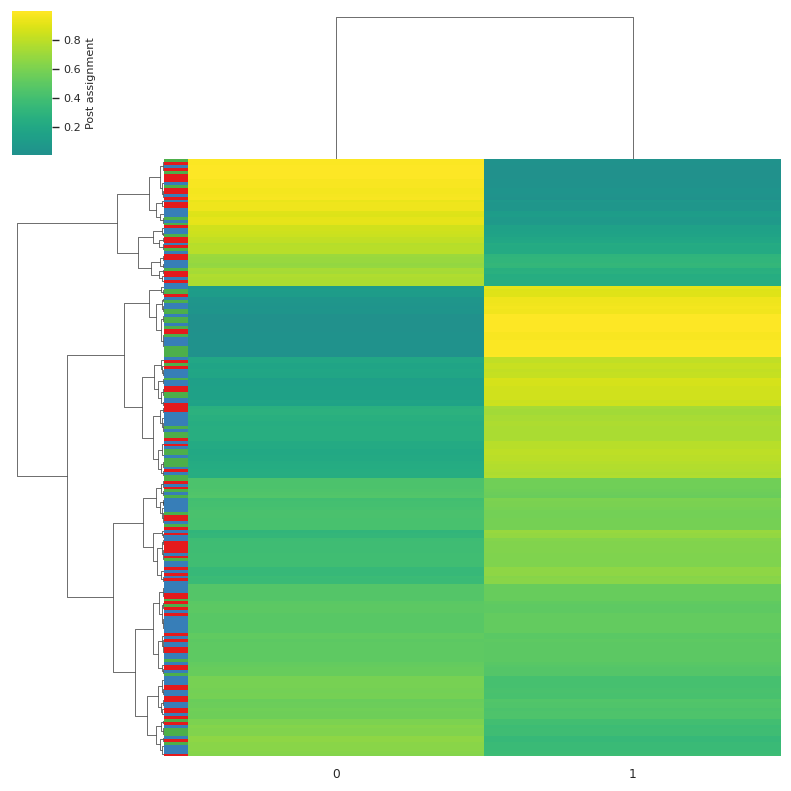

In [125]:
import seaborn as sns

color_palette = sns.color_palette("tab20", n_colors=len(cell_ids_conversion['clean_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['clean_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.clean_cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)


In [126]:
cell_type_colors

{'no class': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 'Glutamatergic': (0.21568627450980393,
  0.49411764705882355,
  0.7215686274509804),
 'GABAergic': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)}

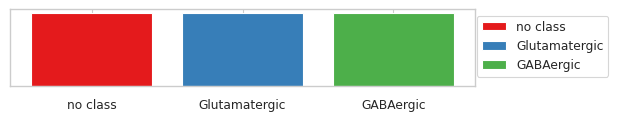

In [127]:
fig, ax = plt.subplots(figsize=(6, 1))

colors=cell_type_colors
for i, (label, color) in enumerate(colors.items()):
    ax.bar(i, 1, color=color, label=label)

ax.set_xticks(range(len(colors)))
ax.set_xticklabels(colors.keys())
ax.set_yticks([])
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.show()

In [128]:
# which junctions are different between these two cell states? 
final_data[final_data["junction_id_index"] == 4]

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id
4,0,4,6.0,7,1.0,0.857143,F2S4_170405_005_A01,no class,1_172551626_172553259,35,ENSG00000094975.15
26187,10,4,9.0,24,15.0,0.375000,F2S4_170405_006_D01,no class,1_172551626_172553259,35,ENSG00000094975.15
29659,11,4,21.0,38,17.0,0.552632,F2S4_170405_006_E01,GABAergic,1_172551626_172553259,35,ENSG00000094975.15
44034,16,4,0.0,10,10.0,0.000000,F2S4_170405_007_B01,Glutamatergic,1_172551626_172553259,35,ENSG00000094975.15
89044,30,4,0.0,11,11.0,0.000000,F2S4_170405_009_C01,Glutamatergic,1_172551626_172553259,35,ENSG00000094975.15
98816,33,4,6.0,20,14.0,0.300000,F2S4_170405_009_F01,GABAergic,1_172551626_172553259,35,ENSG00000094975.15
128041,44,4,0.0,9,9.0,0.000000,F2S4_170405_011_B01,no class,1_172551626_172553259,35,ENSG00000094975.15
197094,65,4,10.0,20,10.0,0.500000,F2S4_170405_014_A01,Glutamatergic,1_172551626_172553259,35,ENSG00000094975.15
224545,74,4,0.0,8,8.0,0.000000,F2S4_170405_015_C01,Glutamatergic,1_172551626_172553259,35,ENSG00000094975.15
228496,75,4,6.0,18,12.0,0.333333,F2S4_170405_015_D01,no class,1_172551626_172553259,35,ENSG00000094975.15


## TO-DO: 

1. Run multiple models with/without a+b global learning parameters, binomial vs beta-binomial to see which gives the best fit on imputated values 
2. Implement function to test which junctions or intron clusters or genes contribute the most to specific cell states --> get marker splicing events 
3. Also figure out a way to map onto gene expression based cell types 